---
## Practical work: build a RFM segmentation

### Objectives :
- Apply a RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior.
- Analyze the migrration of customers between segments over 2015 and 2016.


---

### Import libraies and load data

In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime

In [15]:
mypath = "Data"
CUSTOMER = pd.read_csv(mypath +"\\CUSTOMER.csv")
CUSTOMER_ADDITIONAL = pd.read_csv(mypath + "\\CUSTOMER_ADDITIONAL.csv")
PRODUCTS = pd.read_csv(mypath + "\\PRODUCTS.csv")
RECEIPTS = pd.read_csv(mypath + "\\RECEIPTS.csv")
REFERENTIAL = pd.read_csv(mypath + "\\REFERENTIAL.csv", low_memory=False)
STORE = pd.read_csv(mypath + "\\STORE.csv")

## 2 Selection and merging of the data

- Build the CUSTOMERS_INFO table containing all the information about a customer


In [16]:
CUSTOMERS_INFO = pd.merge(CUSTOMER, CUSTOMER_ADDITIONAL, on="ID_INDIVIDU")
CUSTOMERS_INFO.head()

,ID_INDIVIDU,ID_FOYER,CIVILITE,SEXE,PROFESSION,CATEGORIE_PROF,DATE_NAISS_A,DATE_NAISS_M,DATE_NAISS_J,DATE_CREATION_CARTE,CODE_MAGASIN,PAYS,ETAT,TAILLE,TAILLE_SG,TAILLE_BONNET
0,4,175898,0,0,NaN,NaN,NaN,NaN,NaN,01/01/1989,751,FR,N,38.0,95.0,B
1,27,0,3,2,NaN,3.0,1967.0,9.0,1.0,08/08/2007,942,FR,N,38.0,85.0,B
2,34,127060,3,2,NaN,6.0,1953.0,3.0,4.0,27/07/2007,942,FR,N,42.0,95.0,B
3,37,0,2,2,NaN,3.0,1964.0,8.0,21.0,11/07/2007,942,FR,N,42.0,90.0,B
4,47,0,3,2,NaN,NaN,1972.0,3.0,31.0,23/04/2008,941,FR,N,40.0,90.0,C


In [17]:
CUSTOMERS_INFO.rename(columns={"CODE_MAGASIN":"MANAGING_STORE"}, inplace=True)

- Build `RECEIPTS_INFO` merging tables `RECEIPTS` and `REFERENTIAL`:

In [18]:
# We decide to convert the type of `EAN` in `str`!
RECEIPTS['EAN'] = RECEIPTS['EAN'].astype("str")
RECEIPTS_INFO = pd.merge(RECEIPTS, REFERENTIAL, on="EAN", how="left")
RECEIPTS_INFO.head()

,DATE_ACHAT,EAN,ID_INDIVIDU,ID_FOYER,CODE_LIGNE,TYPE_LIGNE,NUM_TICKET,QUANTITE,PRIX_AP_REMISE,REMISE,REMISE_VALEUR,CODE_BOUTIQUE,ID_ARTICLE,ID_MODELE,ID_OPTION,MODELE,OPTION_PTT,COLORIS,POSITION,GRILLE
0,"""14/12/2013""",3585211297939,4,0,81,"""SALE""",29,1,28,0,0,756,41656.0,21.0,1249.0,128,PROME,10.0,2.0,10.0
1,"""14/12/2015""",3585211731150,4,175898,81,"""SALE""",10,1,69,0,0,730,60020.0,116.0,12128.0,222,MERVE,41.0,4.0,3.0
2,"""14/12/2013""",3585210149062,4,0,81,"""SALE""",29,1,0,0,100,756,150.0,7.0,136.0,FAVORI,AGEND,13.0,1.0,5.0
3,"""14/12/2013""",3585211405723,4,0,81,"""SALE""",29,1,23,0,0,756,45761.0,19.0,3056.0,122,SULFU,93.0,1.0,10.0
4,"""02/07/2016""",3585211668319,4,175898,81,"""SALE""",513,1,75,0,0,920,54398.0,136.0,8251.0,503,CAPFE,20.0,4.0,3.0


Add information to the `RECEIPTS` table with `PRODUCTS` and `STORE`:
- Add product information from the `PRODUCTS` table

In [19]:
RECEIPTS_INFO = pd.merge(RECEIPTS_INFO, PRODUCTS[["MODELE", "Ligne", "Famille"]], on="MODELE", how="left")
RECEIPTS_INFO.head()

,DATE_ACHAT,EAN,ID_INDIVIDU,ID_FOYER,CODE_LIGNE,TYPE_LIGNE,NUM_TICKET,QUANTITE,PRIX_AP_REMISE,REMISE,...,ID_ARTICLE,ID_MODELE,ID_OPTION,MODELE,OPTION_PTT,COLORIS,POSITION,GRILLE,Ligne,Famille
0,"""14/12/2013""",3585211297939,4,0,81,"""SALE""",29,1,28,0,...,41656.0,21.0,1249.0,128,PROME,10.0,2.0,10.0,Corseterie,String/Tanga
1,"""14/12/2015""",3585211731150,4,175898,81,"""SALE""",10,1,69,0,...,60020.0,116.0,12128.0,222,MERVE,41.0,4.0,3.0,Homewear,Homewear_Ensemble
2,"""14/12/2013""",3585210149062,4,0,81,"""SALE""",29,1,0,0,...,150.0,7.0,136.0,FAVORI,AGEND,13.0,1.0,5.0,NaN,NaN
3,"""14/12/2013""",3585211405723,4,0,81,"""SALE""",29,1,23,0,...,45761.0,19.0,3056.0,122,SULFU,93.0,1.0,10.0,Corseterie,String/Tanga
4,"""02/07/2016""",3585211668319,4,175898,81,"""SALE""",513,1,75,0,...,54398.0,136.0,8251.0,503,CAPFE,20.0,4.0,3.0,Bain,Bain_Maillot


- Add store information from the `STORE` table

In [20]:
RECEIPTS_INFO = pd.merge(RECEIPTS_INFO, STORE[["CODE_BOUTIQUE", "REGIONS", "CENTRE_VILLE", "TYPE_MAGASIN", "REGIONS_COMMERCIAL"]], on="CODE_BOUTIQUE", how="left")
RECEIPTS_INFO.head()

,DATE_ACHAT,EAN,ID_INDIVIDU,ID_FOYER,CODE_LIGNE,TYPE_LIGNE,NUM_TICKET,QUANTITE,PRIX_AP_REMISE,REMISE,...,OPTION_PTT,COLORIS,POSITION,GRILLE,Ligne,Famille,REGIONS,CENTRE_VILLE,TYPE_MAGASIN,REGIONS_COMMERCIAL
0,"""14/12/2013""",3585211297939,4,0,81,"""SALE""",29,1,28,0,...,PROME,10.0,2.0,10.0,Corseterie,String/Tanga,Paris,Centre ville,Succursale,Paris
1,"""14/12/2015""",3585211731150,4,175898,81,"""SALE""",10,1,69,0,...,MERVE,41.0,4.0,3.0,Homewear,Homewear_Ensemble,Province,Centre ville,Affilié,Province
2,"""14/12/2013""",3585210149062,4,0,81,"""SALE""",29,1,0,0,...,AGEND,13.0,1.0,5.0,NaN,NaN,Paris,Centre ville,Succursale,Paris
3,"""14/12/2013""",3585211405723,4,0,81,"""SALE""",29,1,23,0,...,SULFU,93.0,1.0,10.0,Corseterie,String/Tanga,Paris,Centre ville,Succursale,Paris
4,"""02/07/2016""",3585211668319,4,175898,81,"""SALE""",513,1,75,0,...,CAPFE,20.0,4.0,3.0,Bain,Bain_Maillot,Paris,Centre Commercial,Succursale,Paris


## Data cleaning and feature engineering

In [40]:
# Drop unneeded columns
RECEIPTS_INFO = RECEIPTS_INFO.drop(columns=["REGIONS_COMMERCIAL"])
# Cleaning 'CENTRE_VILLE' column
RECEIPTS_INFO['CENTRE_VILLE'] = RECEIPTS_INFO["CENTRE_VILLE"].replace("Centre Co", "Centre Commercial")
# Drop unneeded columns
RECEIPTS_INFO = RECEIPTS_INFO.drop(columns=["CODE_LIGNE", "TYPE_LIGNE"])
# Drop unneeded columns
RECEIPTS_INFO = RECEIPTS_INFO.drop(columns=["REMISE"])
# Cap REMISE_VALEUR at 100
RECEIPTS_INFO['REMISE_VALEUR'] = RECEIPTS_INFO.loc[RECEIPTS_INFO["REMISE_VALEUR"]>100, "REMISE_VALEUR"]=100
# Feature engineering
RECEIPTS_INFO['PLV'] = np.where(RECEIPTS_INFO["MODELE"]=="PLV", 1, 0)
RECEIPTS_INFO['Gift'] = np.where((RECEIPTS_INFO["MODELE"].isin(["FAVO", "FAVORI"])) & (RECEIPTS_INFO["PRIX_AP_REMISE"]==0),1,0)
RECEIPTS_INFO['Entry-level'] = np.where(RECEIPTS_INFO["MODELE"]=="ACCESS", 1, 0)

### Save the dataframes `RECEIPTS_INFO`:

In [ ]:
RECEIPTS_INFO.to_csv(mypath +"\\RECEIPTS_INFO.csv",index=False)

---
## Date preparation

- Handle `DATE_ACHAT`

In [45]:
# Create a copy of RECEIPTS_INFO to work on date features
RECEIPTS_INFO_OK = RECEIPTS_INFO.copy()
RECEIPTS_INFO_OK["DATE_ACHAT"] = RECEIPTS_INFO_OK["DATE_ACHAT"].str.replace('"',"",regex=False)
RECEIPTS_INFO_OK["DATE_ACHAT"] = pd.to_datetime(RECEIPTS_INFO_OK["DATE_ACHAT"])

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\2002087782.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  RECEIPTS_INFO_OK["DATE_ACHAT"] = pd.to_datetime(RECEIPTS_INFO_OK["DATE_ACHAT"])


- Compute the final price of a purchase with `PRIX_AP_REMISE` x `QUANTITE`.

In [46]:
RECEIPTS_INFO_OK["PRIX"] = RECEIPTS_INFO_OK["PRIX_AP_REMISE"] * RECEIPTS_INFO_OK["QUANTITE"]

---
### Build the RFM:
#### Create TWO new dfs:
- `RECEIPTS_INFO_RFM_2016`: only keep purchases made in  season 2016 (from september 1, 2015 to august 31, 2016)
- `RECEIPTS_INFO_RFM_2015`: only keep purchases made in 2015 (season 2015: from september 1, 2014 to august 31, 2015)

In [48]:
min_date_RFM_2016 = "2015-08-31"
max_date_RFM_2016 = pd.to_datetime("2016-08-31")

min_date_RFM_2015 = RECEIPTS_INFO_OK['DATE_ACHAT'].max() - pd.DateOffset(days=365*2)
max_date_RFM_2015 = RECEIPTS_INFO_OK['DATE_ACHAT'].max() - pd.DateOffset(days=365)

- Build the `RECEIPTS_INFO_RFM` tables filtered on **the period for RFM analysis**

In [51]:
RECEIPTS_INFO_RFM_2016 = RECEIPTS_INFO_OK[
    (RECEIPTS_INFO_OK.DATE_ACHAT >= min_date_RFM_2016) 
    & (RECEIPTS_INFO_OK.DATE_ACHAT <= max_date_RFM_2016 )
]

RECEIPTS_INFO_RFM_2015 = RECEIPTS_INFO_OK[
    (RECEIPTS_INFO_OK.DATE_ACHAT >= min_date_RFM_2015) 
    & (RECEIPTS_INFO_OK.DATE_ACHAT <= max_date_RFM_2015 )
]

--- 
### Build `VISIT_VALUE` tables: 
- `PRIX`: Sum of `PRIX`for each visit of a customer.
- `QUANTITE`: Sum of `QUANTITE` for each visit of a customer.

In [60]:
VISIT_VALUE_2016 = (
    RECEIPTS_INFO_RFM_2016
    .groupby(['DATE_ACHAT', 'CODE_BOUTIQUE', 'ID_INDIVIDU',
    'NUM_TICKET'])
    .aggregate({'PRIX': 'sum', 'QUANTITE': 'sum'})
    .reset_index()
)
#2015
VISIT_VALUE_2015 = (
    RECEIPTS_INFO_RFM_2015
    .groupby(['DATE_ACHAT', 'CODE_BOUTIQUE', 'ID_INDIVIDU',
    'NUM_TICKET'])
    .aggregate({'PRIX': 'sum', 'QUANTITE': 'sum'})
    .reset_index()
)
VISIT_VALUE_2015.head()

,DATE_ACHAT,CODE_BOUTIQUE,ID_INDIVIDU,NUM_TICKET,PRIX,QUANTITE
0,2014-09-01,62,171881,4,166,5
1,2014-09-01,63,179920,13,148,5
2,2014-09-01,130,120673,20,87,2
3,2014-09-01,130,136287,22,58,2
4,2014-09-01,130,140739,24,109,3


- Rename columns PRIX and QUANTITE to `VISIT_VALUE` and `NB_PRODUCTS`

In [61]:
VISIT_VALUE_2016.columns = [
    'DATE_ACHAT', 'CODE_BOUTIQUE', 'ID_INDIVIDU',
    'NUM_TICKET', 'VISIT_VALUE', 'NB_PRODUCTS'
]

VISIT_VALUE_2015.columns = [
    'DATE_ACHAT', 'CODE_BOUTIQUE', 'ID_INDIVIDU',
    'NUM_TICKET', 'VISIT_VALUE', 'NB_PRODUCTS'
]

- Create a new column `AVG_PRICE`: average price per product for each visit

In [ ]:
VISIT_VALUE_2016["AVG_PRICE"] = VISIT_VALUE_2016["VISIT_VALUE"]/VISIT_VALUE_2016["NB_PRODUCTS"]

VISIT_VALUE_2015["AVG_PRICE"] = VISIT_VALUE_2015["VISIT_VALUE"]/VISIT_VALUE_2015["NB_PRODUCTS"]

---
### Calculate the Frequency per individual
For each individual, we compute:
- `NB_VISITS`: the number of visits,
- `CUMUL_VALUE`: sum of monetary value per visit (using `VISIT_VALUE` computed before),
- `AVG_VISIT_VALUE`: average of monetary value per visit (using `VISIT_VALUE` computed before),
- `AVG_NB_PRODUCTS_VISIT`: average of quantities (using `NB_PRODUCTS` computed before).

In [67]:
agg_dict = {
    'DATE_ACHAT': ['nunique'],
    'VISIT_VALUE': ['mean', 'sum'],
    'NB_PRODUCTS': ['mean']
}

FREQUENCY_2016 = (
    VISIT_VALUE_2016
    .groupby("ID_INDIVIDU")
    .aggregate(agg_dict, drop_index = True)
    .reset_index()
)

FREQUENCY_2015 = (
    VISIT_VALUE_2015
    .groupby("ID_INDIVIDU")
    .aggregate(agg_dict, drop_index = True)
    .reset_index()
)

FREQUENCY_2016.columns = ['ID_INDIVIDU','NB_VISITS','AVG_VISIT_VALUE','CUMUL_VALUE','AVG_NB_PRODUCTS_VISIT']
FREQUENCY_2015.columns = ['ID_INDIVIDU','NB_VISITS','AVG_VISIT_VALUE','CUMUL_VALUE','AVG_NB_PRODUCTS_VISIT']

FREQUENCY_2015.head()

,ID_INDIVIDU,NB_VISITS,AVG_VISIT_VALUE,CUMUL_VALUE,AVG_NB_PRODUCTS_VISIT
0,34,3,69.000000,207,4.00
1,91,4,81.000000,405,3.40
2,99,3,57.666667,173,2.00
3,449,1,66.000000,66,2.00
4,557,4,52.000000,208,1.75


--- 
### Calculate the Recency per individual:
For each individual, we compute:
- `LAST_VISIT_DATE`: date of the last visit
- `RECENCY`: number of days since the last visit (from the end date of the season)


In [68]:
RECENCY_2016 = (
    VISIT_VALUE_2016
    .groupby('ID_INDIVIDU')
    .aggregate({'DATE_ACHAT': 'max'})
    .reset_index()
)

#2015
RECENCY_2015 = (
    VISIT_VALUE_2015
    .groupby('ID_INDIVIDU')
    .aggregate({'DATE_ACHAT': 'max'})
    .reset_index()
)

In [76]:
RECENCY_2016["RECENCY"] = (datetime.strptime("2016-08-31","%Y-%m-%d") - RECENCY_2016["DATE_ACHAT"]) / np.timedelta64(1, 'D')
RECENCY_2015["RECENCY"] = (datetime.strptime("2015-09-01","%Y-%m-%d") - RECENCY_2015["DATE_ACHAT"]) / np.timedelta64(1, 'D')
RECENCY_2016.head(2)

,ID_INDIVIDU,DATE_ACHAT,RECENCY
0,4,2016-07-23,39.0
1,91,2016-04-10,143.0


---

You can check your result with these checks:
- For individu 4, recency is 39 days.
- For individu 91, recency is 91 days.

### Diversification in terms of stores, lines, families and gifts:

- `STORE:`

In [77]:
DIVERS_STORE_2016 = (
    RECEIPTS_INFO_RFM_2016
    .groupby("ID_INDIVIDU")["CODE_BOUTIQUE"]
    .nunique()
    .reset_index()
)

#2015
DIVERS_STORE_2015 = (
    RECEIPTS_INFO_RFM_2015
    .groupby("ID_INDIVIDU")["CODE_BOUTIQUE"]
    .nunique()
    .reset_index()
)

DIVERS_STORE_2016.columns = ['ID_INDIVIDU', 'NB_STORES']
DIVERS_STORE_2015.columns = ['ID_INDIVIDU', 'NB_STORES']

- `LIGNE:`

In [78]:
DIVERS_LINE_2016 = (
    RECEIPTS_INFO_RFM_2016
    .groupby("ID_INDIVIDU")["Ligne"]
    .nunique()
    .reset_index()
)

#2015
DIVERS_LINE_2015 = (
    RECEIPTS_INFO_RFM_2015
    .groupby("ID_INDIVIDU")["Ligne"]
    .nunique()
    .reset_index()
)
DIVERS_LINE_2016.columns = ['ID_INDIVIDU', 'NB_LINES']
DIVERS_LINE_2015.columns = ['ID_INDIVIDU', 'NB_LINES']

- `FAMILLE:`

In [80]:
DIVERS_FAM_2016 = (
    RECEIPTS_INFO_RFM_2016
    .groupby("ID_INDIVIDU")["Famille"]
    .nunique()
    .reset_index()
)

DIVERS_FAM_2015 = (
    RECEIPTS_INFO_RFM_2015
    .groupby("ID_INDIVIDU")["Famille"]
    .nunique()
    .reset_index()
)
DIVERS_FAM_2016.columns = ['ID_INDIVIDU', 'NB_FAMILIES']
DIVERS_FAM_2015.columns = ['ID_INDIVIDU', 'NB_FAMILIES']

- `GIFT:`

In [82]:
NB_GIFTS_2016 = (
    RECEIPTS_INFO_RFM_2016
     .groupby('ID_INDIVIDU')
    .aggregate({'Gift': 'sum'})
    .reset_index()
)

#2015
NB_GIFTS_2015 = (
    RECEIPTS_INFO_RFM_2015
     .groupby('ID_INDIVIDU')
    .aggregate({'Gift': 'sum'})
    .reset_index()
)


NB_GIFTS_2016.columns = ['ID_INDIVIDU', 'NB_GIFTS']
NB_GIFTS_2015.columns = ['ID_INDIVIDU', 'NB_GIFTS']

#####  Join `VISIT_VALUE` (only keeping ID INDIVIDU and CODE BOUTIQUE) and `CUSTOMERS_INFO` (only keeping ID INDIVIDU and MANAGING STORE).

In [84]:
MANAGING_STORE_2016 = (
    VISIT_VALUE_2016[['ID_INDIVIDU', 'CODE_BOUTIQUE']]
    .merge(CUSTOMERS_INFO[['ID_INDIVIDU', 'MANAGING_STORE']], 
           on='ID_INDIVIDU', 
           how='inner')
)

#2015
MANAGING_STORE_2015 = (
    VISIT_VALUE_2015[['ID_INDIVIDU', 'CODE_BOUTIQUE']]
    .merge(CUSTOMERS_INFO[['ID_INDIVIDU', 'MANAGING_STORE']],
              on='ID_INDIVIDU',
                how='inner')
)
# Create a column to see if the store of purchase is the same as the managing store.
MANAGING_STORE_2016["TOP_MANAGING_STORE"] = (MANAGING_STORE_2016['CODE_BOUTIQUE'] == MANAGING_STORE_2016['MANAGING_STORE']).astype(int)
MANAGING_STORE_2015["TOP_MANAGING_STORE"] = (MANAGING_STORE_2015['CODE_BOUTIQUE'] == MANAGING_STORE_2015['MANAGING_STORE']).astype(int)

MANAGING_STORE_2016

In [85]:
SHARE_MANAGING_STORE_2016 = (
    MANAGING_STORE_2016
    .groupby('ID_INDIVIDU')
    .size()
    .div(len(MANAGING_STORE_2016))
    .reset_index(name='SHARE_MANAGING_STORE')
)

SHARE_MANAGING_STORE_2015 = (
    MANAGING_STORE_2015
    .groupby('ID_INDIVIDU')
    .size()
    .div(len(MANAGING_STORE_2015))
    .reset_index(name='SHARE_MANAGING_STORE')
)

SHARE_MANAGING_STORE_2016.head()

,ID_INDIVIDU,SHARE_MANAGING_STORE
0,4,0.000194
1,91,0.000032
2,99,0.000097
3,557,0.000194
4,1396,0.000258


### Data preparation for `CUSTOMERS_INFO`: 


In [88]:
# Copy of CUSTOMERS_INFO to work on it:
CUSTOMERS_INFO_OK = CUSTOMERS_INFO.copy()

- `AGE:`

In [93]:
CUSTOMERS_INFO_OK["BIRTH_YEAR"] = CUSTOMERS_INFO_OK["DATE_NAISS_A"]
CUSTOMERS_INFO_OK["BIRTH_MONTH"] = CUSTOMERS_INFO_OK["DATE_NAISS_M"]
CUSTOMERS_INFO_OK["BIRTH_DAY"] = CUSTOMERS_INFO_OK["DATE_NAISS_J"]

CUSTOMERS_INFO_OK["BIRTH_DATE"] = pd.to_datetime(
    dict(
        year = CUSTOMERS_INFO_OK["BIRTH_YEAR"], 
        month = CUSTOMERS_INFO_OK["BIRTH_MONTH"], 
        day = CUSTOMERS_INFO_OK["BIRTH_DAY"]
    ),
    errors  = 'coerce'
)

CUSTOMERS_INFO_OK["AGE_2016"] = 2016 - CUSTOMERS_INFO_OK["BIRTH_YEAR"]
CUSTOMERS_INFO_OK["AGE_2015"] = 2015 - CUSTOMERS_INFO_OK["BIRTH_YEAR"]

- Data cleaning: handle outliers and missing values

In [97]:
CUSTOMERS_INFO_OK["AGE_2016"] = CUSTOMERS_INFO_OK["AGE_2016"].where((CUSTOMERS_INFO_OK["AGE_2016"] >= 15) & (CUSTOMERS_INFO_OK["AGE_2016"] <= 90), np.nan)
CUSTOMERS_INFO_OK["AGE_2015"] = CUSTOMERS_INFO_OK["AGE_2015"].where((CUSTOMERS_INFO_OK["AGE_2015"] >= 15) & (CUSTOMERS_INFO_OK["AGE_2015"] <= 90), np.nan)

- `SENIORITY:`

In [98]:
CUSTOMERS_INFO_OK["DATE_CREATION_CARTE"] = pd.to_datetime(CUSTOMERS_INFO_OK["DATE_CREATION_CARTE"], format="%d/%m/%Y")
CUSTOMERS_INFO_OK["SENIORITY_2016"] = (max_date_RFM_2016 - CUSTOMERS_INFO_OK['DATE_CREATION_CARTE']).dt.days
CUSTOMERS_INFO_OK["SENIORITY_2015"] = (max_date_RFM_2015 - CUSTOMERS_INFO_OK['DATE_CREATION_CARTE']).dt.days

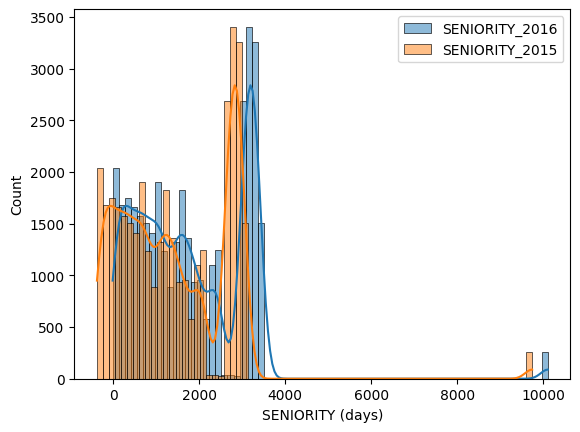

In [ ]:
import matplotlib.pyplot as plt
sns.histplot(CUSTOMERS_INFO_OK["SENIORITY_2016"], label="SENIORITY_2016", kde=True)
sns.histplot(CUSTOMERS_INFO_OK["SENIORITY_2015"], label="SENIORITY_2015", kde=True)
plt.xlabel("SENIORITY (days)")
plt.legend()    

- Outliers handling:

In [114]:
CUSTOMERS_INFO_OK["SENIORITY_2016"] = CUSTOMERS_INFO_OK["SENIORITY_2016"].where(CUSTOMERS_INFO_OK["SENIORITY_2016"] <= 3650, np.nan)
CUSTOMERS_INFO_OK["SENIORITY_2016"] = CUSTOMERS_INFO_OK["SENIORITY_2016"].clip(lower=0)

CUSTOMERS_INFO_OK["SENIORITY_2015"] = CUSTOMERS_INFO_OK["SENIORITY_2015"].where(CUSTOMERS_INFO_OK["SENIORITY_2015"] <= 3650, np.nan)
CUSTOMERS_INFO_OK["SENIORITY_2015"] = CUSTOMERS_INFO_OK["SENIORITY_2015"].clip(lower=0)


### Gather all features into `MASTER_2016` and `MASTER_2015`:



- Join `CUSTOMERS_INFO_OK` with `SHARE_MANAGING_STORE`

In [142]:
## reset MASTER df's
MASTER_2016= pd.DataFrame()
MASTER_2015= pd.DataFrame()

In [143]:
MASTER_2016 = (
    CUSTOMERS_INFO_OK[['ID_INDIVIDU', 'CIVILITE', 'SEXE', 'PROFESSION', 'CATEGORIE_PROF', 'DATE_CREATION_CARTE', 'MANAGING_STORE', 'AGE', 'SENIORITY_2016']]
    .merge(SHARE_MANAGING_STORE_2016[['ID_INDIVIDU','SHARE_MANAGING_STORE']], 
           on='ID_INDIVIDU', 
           how='inner')
)

MASTER_2015 = (
    CUSTOMERS_INFO_OK[['ID_INDIVIDU', 'CIVILITE', 'SEXE', 'PROFESSION', 'CATEGORIE_PROF', 'DATE_CREATION_CARTE', 'MANAGING_STORE', 'AGE', 'SENIORITY_2015']]
    .merge(SHARE_MANAGING_STORE_2015[['ID_INDIVIDU','SHARE_MANAGING_STORE']], 
           on='ID_INDIVIDU', 
           how='inner')
)

- Join `MASTER` with `GIFTS`

In [144]:
MASTER_2016 = MASTER_2016.merge(NB_GIFTS_2016[['ID_INDIVIDU','NB_GIFTS']], 
           on='ID_INDIVIDU', 
           how='inner')

MASTER_2015 = MASTER_2015.merge(NB_GIFTS_2015[['ID_INDIVIDU','NB_GIFTS']], 
           on='ID_INDIVIDU', 
           how='inner')

- Join `MASTER` with `NB_STORES`

In [145]:
MASTER_2016 = MASTER_2016.merge(DIVERS_STORE_2016[['ID_INDIVIDU','NB_STORES']], 
           on='ID_INDIVIDU', 
           how='inner')

MASTER_2015 = MASTER_2015.merge(DIVERS_STORE_2015[['ID_INDIVIDU','NB_STORES']], 
           on='ID_INDIVIDU', 
           how='inner')

- Join `MASTER` with `NB_LINES`

In [146]:
MASTER_2016 = MASTER_2016.merge(DIVERS_LINE_2016[['ID_INDIVIDU','NB_LINES']], 
           on='ID_INDIVIDU', 
           how='inner')

MASTER_2015 = MASTER_2015.merge(DIVERS_LINE_2015[['ID_INDIVIDU','NB_LINES']], 
           on='ID_INDIVIDU', 
           how='inner')

- Join `MASTER` with `NB_FAMILIES`

In [147]:
MASTER_2016 = MASTER_2016.merge(DIVERS_FAM_2016[['ID_INDIVIDU','NB_FAMILIES']], 
           on='ID_INDIVIDU', 
           how='inner')

MASTER_2015 = MASTER_2015.merge(DIVERS_FAM_2015[['ID_INDIVIDU','NB_FAMILIES']], 
           on='ID_INDIVIDU', 
           how='inner')

- Join `MASTER` with `RECENCY`

In [148]:
MASTER_2016 = MASTER_2016.merge(RECENCY_2016[['ID_INDIVIDU','RECENCY']], 
           on='ID_INDIVIDU', 
           how='inner')
    
MASTER_2015 = MASTER_2015.merge(RECENCY_2015[['ID_INDIVIDU','RECENCY']], 
           on='ID_INDIVIDU', 
           how='inner')

- Join `MASTER` with `NB_VISITS`

In [149]:
MASTER_2016 = MASTER_2016.merge(FREQUENCY_2016[['ID_INDIVIDU','NB_VISITS']], 
           on='ID_INDIVIDU', 
           how='inner')
    
MASTER_2015 = MASTER_2015.merge(FREQUENCY_2015 [['ID_INDIVIDU','NB_VISITS']], 
           on='ID_INDIVIDU', 
           how='inner')

- Join `MASTER` with `CUMUL_VALUE`

In [150]:
MASTER_2016 = MASTER_2016.merge(FREQUENCY_2016[['ID_INDIVIDU','CUMUL_VALUE']], 
           on='ID_INDIVIDU', 
           how='inner')

MASTER_2015 = MASTER_2015.merge(FREQUENCY_2015[['ID_INDIVIDU','CUMUL_VALUE']], 
           on='ID_INDIVIDU', 
           how='inner')

- Show the number of null values in `MASTER`

In [151]:

#sorted by the number of null values
MASTER_2015.isnull().sum().sort_values(ascending=True)

ID_INDIVIDU                 0
RECENCY                     0
NB_FAMILIES                 0
NB_LINES                    0
NB_STORES                   0
NB_GIFTS                    0
SHARE_MANAGING_STORE        0
NB_VISITS                   0
CUMUL_VALUE                 0
MANAGING_STORE              0
DATE_CREATION_CARTE         0
SEXE                        0
CIVILITE                    0
SENIORITY_2015             10
AGE                        16
CATEGORIE_PROF           4293
PROFESSION              10616
dtype: int64

- Some final checks

In [164]:
MASTER_RFM_2016 = MASTER_2016[MASTER_2016.RECENCY.notnull()].copy()
MASTER_RFM_2015 = MASTER_2015[MASTER_2015.RECENCY.notnull()].copy()
MASTER_RFM_2016['NB_GIFTS'] = NB_GIFTS_2016['NB_GIFTS'].fillna(0)
MASTER_RFM_2015['NB_GIFTS'] = NB_GIFTS_2015['NB_GIFTS'].fillna(0)
MASTER_RFM_2016 = MASTER_RFM_2016.where((MASTER_RFM_2016["AGE"] >= 15) & (MASTER_RFM_2016["AGE"] <= 100), np.nan)
MASTER_RFM_2015 = MASTER_RFM_2015.where((MASTER_RFM_2015["AGE"] >= 15) & (MASTER_RFM_2015["AGE"] <= 100), np.nan)


In [ ]:
# Check if there are issues (for exemple negative values for RECENCY, CUMUL_VALUE, NB_VISITS...)
MASTER_RFM_2016.describe()

### Data visualization:

- `Number of customers` per segment (2015 vs 2016)

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\2972811917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= ['2015', '2016'], y= [CUSTOMER_2015, CUSTOMER_2016],width=0.4, palette=['orange', 'blue'])


<Axes: >

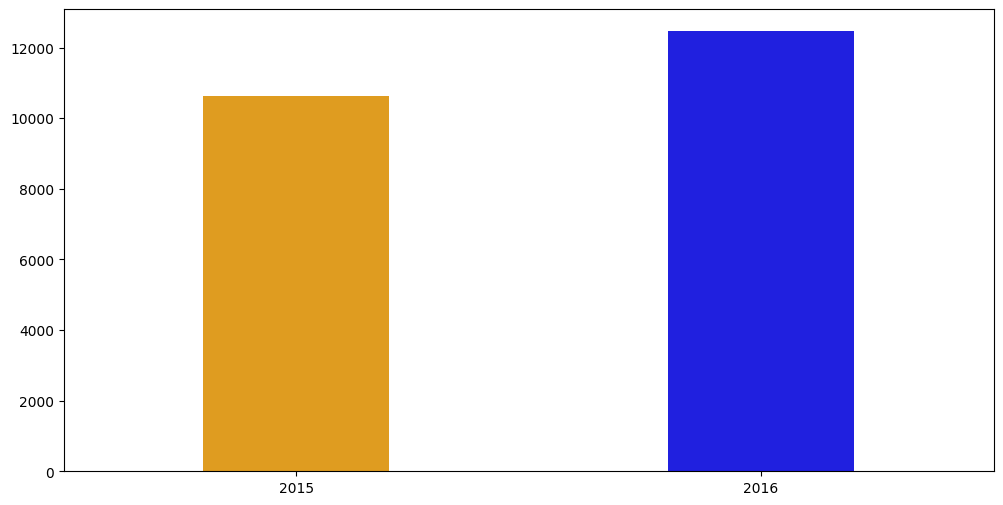

In [185]:
CUSTOMER_2016= len(MASTER_RFM_2016)
CUSTOMER_2015= len(MASTER_RFM_2015)
plt.figure(figsize=(12,6))
#Two colors diff orange for 2015 and blue for 2016
sns.barplot(x= ['2015', '2016'], y= [CUSTOMER_2015, CUSTOMER_2016],width=0.4, palette=['orange', 'blue'])

There are more customers in 2016 than in 2015, indicating growth in the customer base.

- `CUMUL_VALUE` distribution for 2015 and 2016

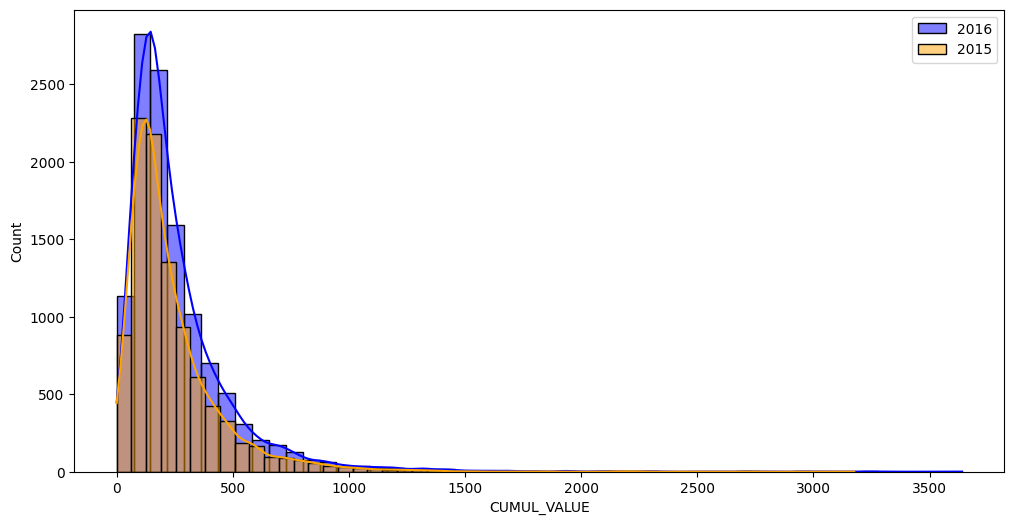

In [167]:
plt.figure(figsize=(12,6))
sns.histplot(MASTER_RFM_2016['CUMUL_VALUE'], bins=50, kde=True, color='blue', label='2016')
sns.histplot(MASTER_RFM_2015['CUMUL_VALUE'], bins=50, kde=True, color='orange', label='2015')
plt.xlabel("CUMUL_VALUE")
plt.legend()

In [186]:
total_value_2016 = MASTER_RFM_2016['CUMUL_VALUE'].sum()
print(f"Total CUMUL_VALUE in 2016: {total_value_2016}")
total_value_2015 = MASTER_RFM_2015['CUMUL_VALUE'].sum()
print(f"Total CUMUL_VALUE in 2015: {total_value_2015}")

mean_value_2016 = MASTER_RFM_2016['CUMUL_VALUE'].mean()
print(f"Mean CUMUL_VALUE in 2016: {mean_value_2016}")
mean_value_2015 = MASTER_RFM_2015['CUMUL_VALUE'].mean()
print(f"Mean CUMUL_VALUE in 2015: {mean_value_2015}")

Total CUMUL_VALUE in 2016: 3040802.0
Total CUMUL_VALUE in 2015: 2342081.0
Mean CUMUL_VALUE in 2016: 263.1817552362818
Mean CUMUL_VALUE in 2015: 238.0163617886179


We can observe that the distribution of CUMUL_VALUE is right-skewed for both years, with a long tail of high spenders. The 2016 distribution appears to have a slightly higher peak and a longer tail compared to 2015, indicating an increase in both the number of moderate spenders and high spenders in 2016. We can verify this by looking at the total `total_value_2016` and `total_value_2015`, which shows an increase from 2015 to 2016. `mean_value_2016` is also higher than `mean_value_2015`, confirming that, on average, customers spent more in 2016 compared to 2015.

- `FREQ` distribution for 2015 and 2016

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\108621717.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(MASTER_RFM_2016['NB_VISITS'], color='blue', label='2016')
C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\108621717.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(MASTER_RFM_2015[

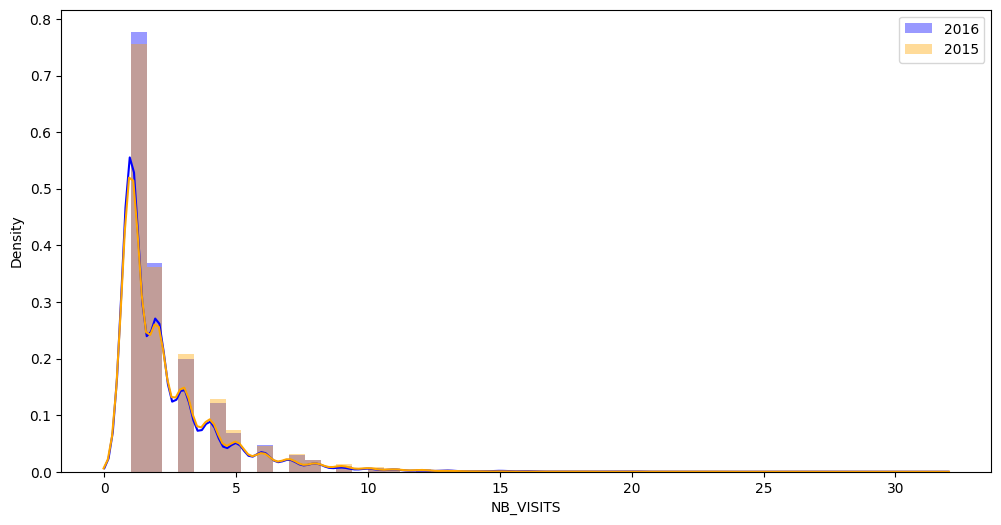

In [197]:
plt.figure(figsize=(12,6))
sns.distplot(MASTER_RFM_2016['NB_VISITS'], color='blue', label='2016')
sns.distplot(MASTER_RFM_2015['NB_VISITS'], color='orange', label='2015')
plt.xlabel("NB_VISITS")
plt.legend()

This plot shows the distribution of the number of visits (FREQ) for customers in 2015 and 2016 is very close.

In [198]:
total_visits_2016 = MASTER_RFM_2016['NB_VISITS'].mean()
print(f"Total NB_VISITS in 2016: {total_visits_2016}")

total_visits_2015 = MASTER_RFM_2015['NB_VISITS'].mean()
print(f"Total NB_VISITS in 2015: {total_visits_2015}")

Total NB_VISITS in 2016: 2.4048814263458542
Total NB_VISITS in 2015: 2.454369918699187


The average number of visits per customer appears to be similar between the two years, suggesting that customer engagement in terms of visit frequency has remained relatively stable from 2015 to 2016.

- Recency distribution for 2015 and 2016

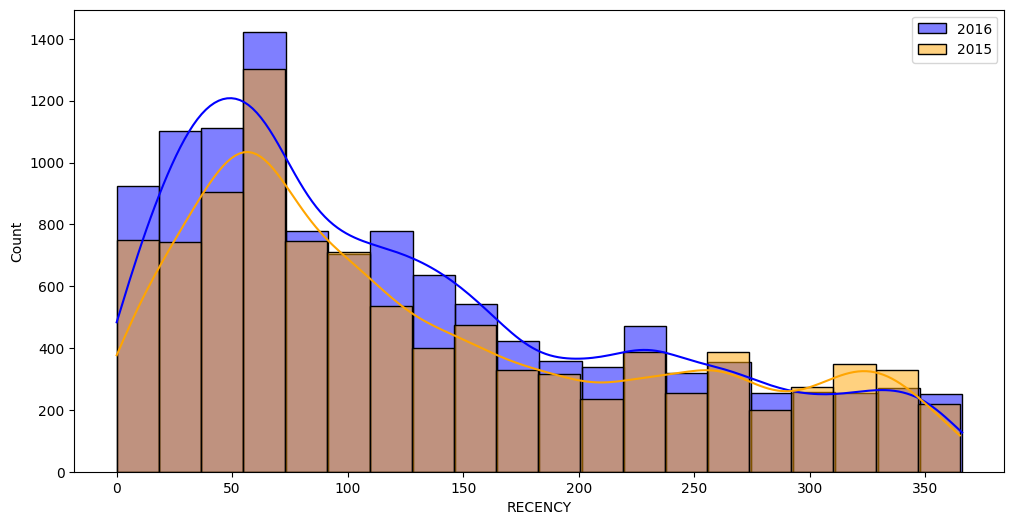

In [207]:
plt.figure(figsize=(12,6))
sns.histplot(MASTER_RFM_2016['RECENCY'], bins=20, kde=True, color='blue', label='2016')
sns.histplot(MASTER_RFM_2015['RECENCY'], bins=20, kde=True, color='orange', label='2015')
plt.xlabel("RECENCY")
plt.legend()
